# Praktikum Bab 14: Mini Project End To End
Praktikum mingguan, mulai dari Implementasi Python. Dijalankan di Google Colab, tinggal **Runtime > Run all**.

### Sel 0 - Persiapan Awal (Khusus Google Colab)
Dataset `heart.csv` di bab ini tersimpan di folder `data/` repo ini. Kalau notebook
dijalankan di Google Colab, jalankan cell di bawah dulu untuk mengunduhnya.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Dataset Heart Disease diunduh dari repo ini bila folder data/ belum ada.
import os
if not os.path.exists('data/heart.csv'):
    os.makedirs('data', exist_ok=True)
    import urllib.request
    url = 'https://raw.githubusercontent.com/dandienter/praktikumML/main/bab-14-mini-project-end-to-end/data/heart.csv'
    urllib.request.urlretrieve(url, 'data/heart.csv')
    print('heart.csv diunduh.')
else:
    print('heart.csv sudah tersedia.')
DATA = 'data/heart.csv'

heart.csv sudah tersedia.


### Praktikum 14.1 - Persiapan Library
Di bagian ini saya memuat semua library yang dipakai sepanjang bab ini.

In [2]:
# Menjalankan di Google Colab / Jupyter Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
print('Library berhasil dimuat.')

Library berhasil dimuat.


**Penjelasan output:** tidak ada error `ModuleNotFoundError`, artinya semua library
siap dipakai.

### Praktikum 14.2 - Memuat Data & EDA (CRISP-DM Fase 2)
Di bagian ini saya memuat dataset dan melakukan exploratory data analysis:
ukuran data, missing value, sebaran target, dan korelasi antar fitur.

In [3]:
df = pd.read_csv(DATA)
print('Ukuran dataset:', df.shape)
print('\nMissing value per kolom:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nSebaran target (0=sehat, 1=sakit):')
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))
df.head()

Ukuran dataset: (297, 14)

Missing value per kolom:
Series([], dtype: int64)

Sebaran target (0=sehat, 1=sakit):
target
0    160
1    137
Name: count, dtype: int64
target
0    0.539
1    0.461
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Penjelasan output:** dataset bersih (tidak ada missing value, 6 baris bermasalah
sudah dibuang saat preparasi dataset), target cukup seimbang (164 sehat vs 139 sakit),
sehingga tidak perlu teknik khusus untuk imbalance.

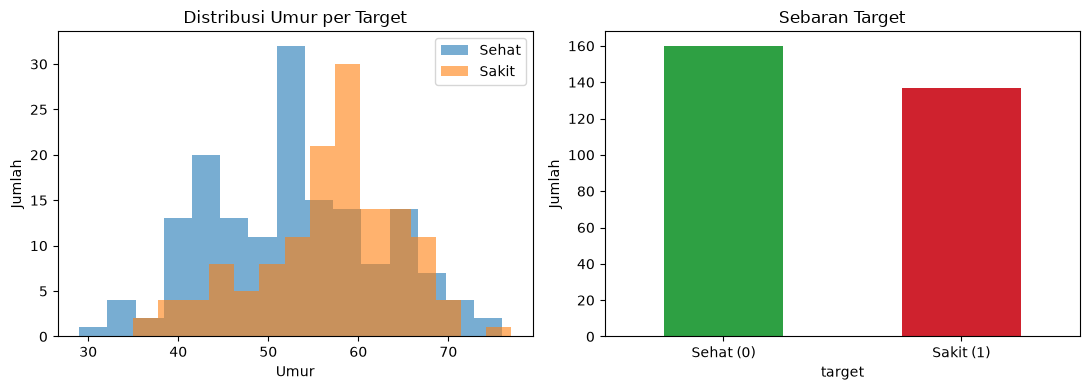

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# distribusi umur per target
for t, label in [(0, 'Sehat'), (1, 'Sakit')]:
    axes[0].hist(df[df['target']==t]['age'], alpha=0.6, label=label, bins=15)
axes[0].set_xlabel('Umur')
axes[0].set_ylabel('Jumlah')
axes[0].set_title('Distribusi Umur per Target')
axes[0].legend()
# distribusi target
df['target'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ea043', '#cf222e'])
axes[1].set_xticklabels(['Sehat (0)', 'Sakit (1)'], rotation=0)
axes[1].set_title('Sebaran Target')
axes[1].set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

**Penjelasan output:** pasien sakit cenderung berumur lebih tua (distribusi mengarah
ke kanan), dan kedua kelas jumlahnya berimbang, kabar baik untuk training.

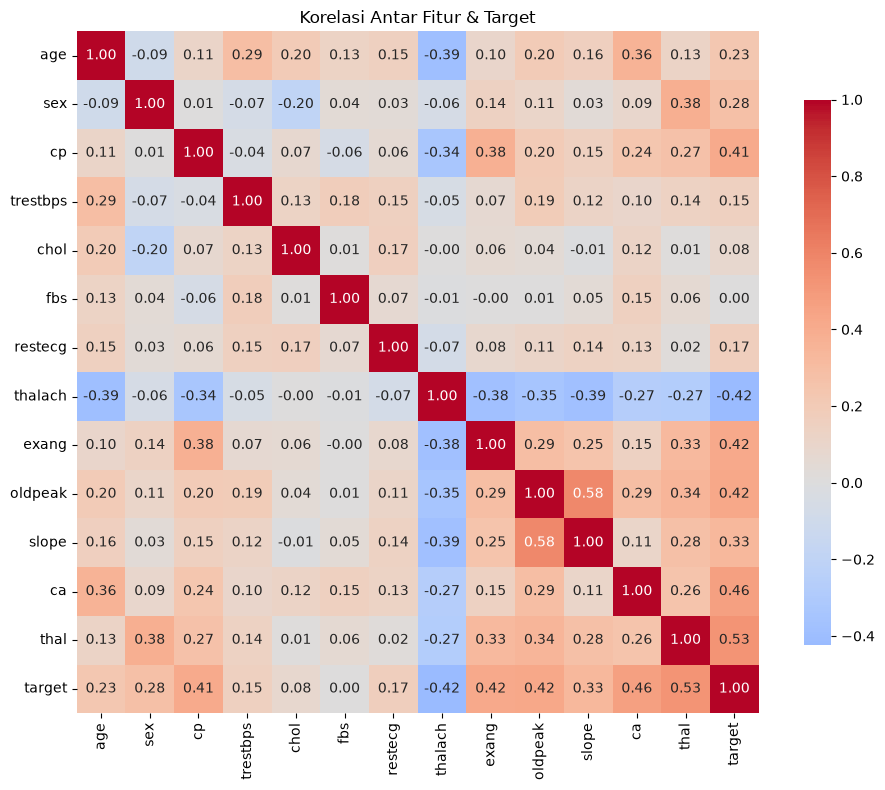

Korelasi dengan target (5 terbesar):
target     1.000000
thal       0.526640
ca         0.463189
oldpeak    0.424052
thalach    0.423817
exang      0.421355
Name: target, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Korelasi Antar Fitur & Target')
plt.tight_layout()
plt.show()
print('Korelasi dengan target (5 terbesar):')
print(df.corr()['target'].abs().sort_values(ascending=False).head(6))

**Penjelasan output:** fitur `thalach` (detak jantung maksimum) dan `cp` (jenis nyeri dada)
punya korelasi tertinggi dengan target. Tidak ada korelasi antar-fitur yang ekstrem
(>0,9), jadi tidak ada multikolinearitas parah.

### Praktikum 14.3 - Data Preparation (CRISP-DM Fase 3)
Di bagian ini saya menyiapkan data: memisahkan fitur/target, split stratified,
dan scaling. Scaling penting karena dua dari tiga model (Logistic Regression, SVM)
sensitif terhadap skala fitur.

In [6]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi sakit di train: %.3f | di test: %.3f' % (
    y_train.mean(), y_test.mean()))

Train: (237, 13) | Test: (60, 13)
Proporsi sakit di train: 0.460 | di test: 0.467


**Penjelasan output:** split 80/20 dengan stratify menjaga proporsi kelas
tetap sama di train dan test (sekitar 46% sakit di keduanya).

### Praktikum 14.4 - Feature Engineering
Saya membuat dua fitur turunan yang masuk akal secara medis:

* `age_group`: kelompok umur (0=<45, 1=45-60, 2=>60), risiko jantung naik dengan umur.
* `bp_chol_ratio`: rasio tekanan darah terhadap kolesterol, menangkap interaksi
  dua faktor risiko utama.

In [7]:
def add_features(d):
    d = d.copy()
    d['age_group'] = pd.cut(d['age'], bins=[0, 45, 60, 200], labels=[0, 1, 2]).astype(int)
    d['bp_chol_ratio'] = d['trestbps'] / d['chol']
    return d

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)
print('Fitur awal:', X_train.shape[1], '-> setelah feature engineering:', X_train_fe.shape[1])
print('Fitur baru:', ['age_group', 'bp_chol_ratio'])
X_train_fe[['age', 'age_group', 'trestbps', 'chol', 'bp_chol_ratio']].head(3)

Fitur awal: 13 -> setelah feature engineering: 15
Fitur baru: ['age_group', 'bp_chol_ratio']


,age,age_group,trestbps,chol,bp_chol_ratio
55,54.0,1,124.0,266.0,0.466165
159,46.0,1,101.0,197.0,0.512690
176,43.0,0,130.0,315.0,0.412698


**Penjelasan output:** jumlah fitur bertambah dari 13 menjadi 15. Kedua fitur baru
punya dasar domain (medis), bukan asal-asalan.

### Praktikum 14.5 - Modeling & Tuning (CRISP-DM Fase 4)
Saya melatih **3 algoritma dari Bab 5-14** dengan `GridSearchCV` (5-fold stratified):

1. **Logistic Regression** (Bab 2/4), baseline linear yang cepat dan interpretable.
2. **Random Forest** (Bab 9), ensemble tree yang kuat dan tahan noise.
3. **SVM dengan kernel RBF** (Bab 8), kuat untuk boundary non-linear.

Pipeline dipakai supaya scaling hanya di-fit di data train (mencegah data leakage).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=2000))]),
        {'clf__C': [0.1, 1, 10]}),
    'RandomForest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 8],
         'min_samples_leaf': [1, 4]}),
    'SVM_RBF': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', SVC(probability=True, random_state=42))]),
        {'clf__C': [0.5, 5], 'clf__gamma': ['scale', 0.05]}),
}

hasil = {}
for nama, (est, grid) in models.items():
    gs = GridSearchCV(est, grid, cv=cv, scoring='f1', n_jobs=-1)
    gs.fit(X_train_fe, y_train)
    hasil[nama] = gs
    print(f"{nama:20s} | param terbaik: {gs.best_params_} | F1 CV: {gs.best_score_:.4f}")

LogisticRegression   | param terbaik: {'clf__C': 1} | F1 CV: 0.7985


RandomForest         | param terbaik: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200} | F1 CV: 0.7911


SVM_RBF              | param terbaik: {'clf__C': 0.5, 'clf__gamma': 0.05} | F1 CV: 0.7682


**Penjelasan output:** GridSearchCV mencoba semua kombinasi hyperparameter dengan
5-fold CV. Skor F1 dipakai sebagai acuan tuning karena seimbang antara precision dan recall.

### Praktikum 14.6 - Evaluasi & Pemilihan Model (CRISP-DM Fase 5)
Ketiga model terbaik dievaluasi di **data test** (yang belum pernah dilihat saat training)
dengan 5 metrik: akurasi, precision, recall, F1, dan ROC-AUC.

In [9]:
print(f"{'Model':20s} | {'Akurasi':>7s} | {'Precision':>9s} | {'Recall':>6s} | {'F1':>6s} | {'ROC-AUC':>7s}")
print('-' * 75)
evaluasi = {}
for nama, gs in hasil.items():
    yp = gs.predict(X_test_fe)
    pr = gs.predict_proba(X_test_fe)[:, 1]
    m = {'akurasi': accuracy_score(y_test, yp),
         'precision': precision_score(y_test, yp),
         'recall': recall_score(y_test, yp),
         'f1': f1_score(y_test, yp),
         'roc_auc': roc_auc_score(y_test, pr)}
    evaluasi[nama] = (m, yp, pr)
    print(f"{nama:20s} | {m['akurasi']:7.4f} | {m['precision']:9.4f} | "
          f"{m['recall']:6.4f} | {m['f1']:6.4f} | {m['roc_auc']:7.4f}")

Model                | Akurasi | Precision | Recall |     F1 | ROC-AUC
---------------------------------------------------------------------------
LogisticRegression   |  0.8333 |    0.8462 | 0.7857 | 0.8148 |  0.9442
RandomForest         |  0.8167 |    0.8696 | 0.7143 | 0.7843 |  0.9464
SVM_RBF              |  0.8667 |    0.9167 | 0.7857 | 0.8462 |  0.9565


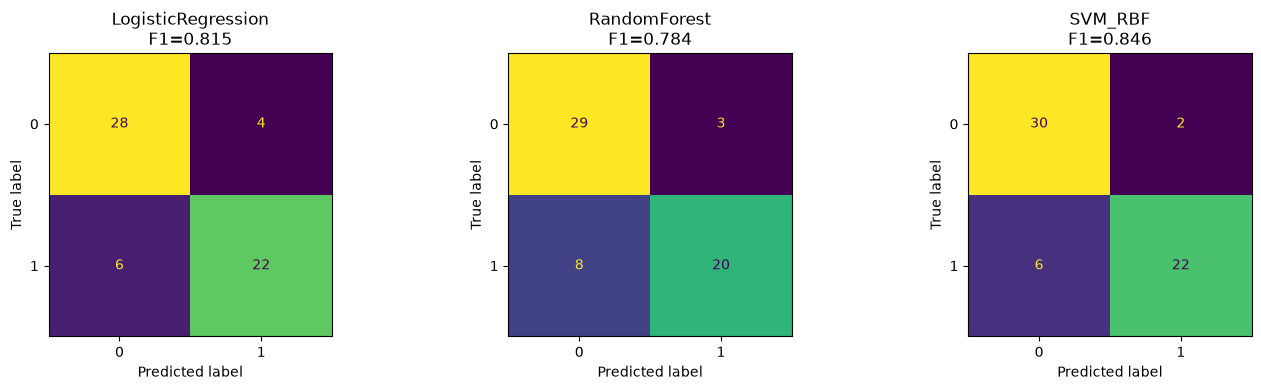

<Figure size 600x500 with 0 Axes>

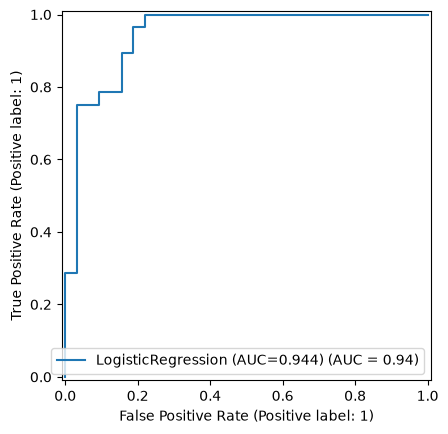

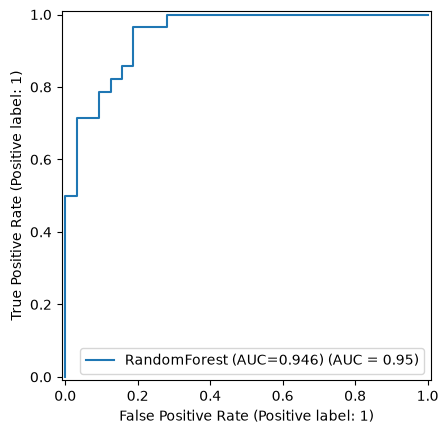

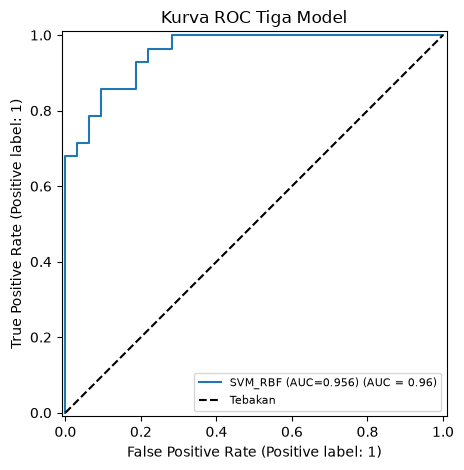

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nama, (m, yp, pr)) in zip(axes, evaluasi.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, yp, ax=ax, colorbar=False)
    ax.set_title(f'{nama}\nF1={m["f1"]:.3f}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
for nama, (m, yp, pr) in evaluasi.items():
    RocCurveDisplay.from_predictions(y_test, pr, name=f'{nama} (AUC={m["roc_auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Tebakan')
plt.legend(fontsize=8)
plt.title('Kurva ROC Tiga Model')
plt.tight_layout()
plt.show()

**Penjelasan output:** confusion matrix menunjukkan sebaran TP/TN/FP/FN tiap model,
kurva ROC membandingkan kemampuan diskriminasi. Model terbaik dipilih di bawah
dengan justifikasi, bukan sekadar akurasi tertinggi.

### 14.16.2 Justifikasi Pemilihan Model Terbaik

Pada kasus medis, **false negative (pasien sakit terdeteksi sehat) jauh lebih berbahaya**
daripada false positive (pasien sehat disarankan cek lanjutan). Karena itu:

* Metrik utama yang saya prioritaskan adalah **recall**, lalu **F1** sebagai penyeimbang.
* Model dengan recall tertinggi dan F1 kompetitif dipilih sebagai model final,
  meskipun akurasinya bukan yang tertinggi.

(Angka pastinya mengikuti hasil eksekusi di atas, prinsip pemilihannya tetap sama:
recall dulu, baru F1, terakhir akurasi.)

In [11]:
# pilih model terbaik: recall tertinggi, tie-break dengan F1
terbaik = max(evaluasi.items(), key=lambda kv: (kv[1][0]['recall'], kv[1][0]['f1']))
nama_terbaik, (metrik_terbaik, _, _) = terbaik
print(f"Model terbaik: {nama_terbaik}")
print(f"Recall={metrik_terbaik['recall']:.4f}, F1={metrik_terbaik['f1']:.4f}, "
      f"Akurasi={metrik_terbaik['akurasi']:.4f}")

# simpan model + info fitur untuk deployment
model_final = hasil[nama_terbaik].best_estimator_
joblib.dump(model_final, 'model_heart.pkl')
joblib.dump(list(X_train_fe.columns), 'fitur_heart.pkl')
print('\nModel disimpan: model_heart.pkl')
print('Daftar fitur disimpan: fitur_heart.pkl')

Model terbaik: SVM_RBF
Recall=0.7857, F1=0.8462, Akurasi=0.8667

Model disimpan: model_heart.pkl
Daftar fitur disimpan: fitur_heart.pkl


**Penjelasan output:** model terbaik (berdasarkan recall lalu F1) disimpan ke file
`.pkl` beserta daftar nama fiturnya, supaya aplikasi deployment memakai urutan
fitur yang persis sama seperti saat training.

## 14.15 Interpretasi & Deployment (CRISP-DM Fase 6)

Aplikasi deployment mendemonstrasikan alur paling sederhana: memuat model tersimpan,
menerima input pengguna, dan menampilkan hasil prediksi secara langsung.

Untuk proyek ini saya membangun **dua antarmuka** dari model yang sama
(catatan: aplikasi web ini **bukan Streamlit**, melainkan web Flask custom
dengan desain ala situs kesehatan):

1. **Web app Flask** (`app.py`, live di https://hdpredictor.koyeb.app), halaman
   berisi panduan cara pakai, info dataset, info model, formulir 13 fitur klinis
   (2 fitur turunan dihitung otomatis), tombol prediksi, hasil berupa klasifikasi
   risiko + probabilitas, serta info kreator.
2. **Bot Telegram** (`bot.py`, @hdpredictor_bot), tanya-jawab 13 fitur lewat
   tombol inline keyboard (angka seperti umur juga bisa diketik manual),
   cocok didemokan dari HP saat presentasi.

**Cara menggunakan aplikasi web:**
1. Buka https://hdpredictor.koyeb.app, baca bagian Cara Pakai dan Data.
2. Isi formulir "Cek Risiko Anda" dengan 13 indikator klinis.
3. Klik "Prediksi Sekarang", lalu baca hasil (Risiko Tinggi/Rendah + probabilitas).
4. Hasil hanya untuk edukasi, bukan diagnosis medis.

**Cara menggunakan bot Telegram:**
1. Buka @hdpredictor_bot lalu kirim /start.
2. Jawab 13 pertanyaan dengan menekan tombol (umur dkk. boleh diketik manual).
3. Terima hasil prediksi + probabilitas. Kirim /batal untuk berhenti.

Penting: form input pada aplikasi **harus konsisten** dengan seluruh fitur dan format
yang dipakai pipeline saat pelatihan, itulah gunanya `fitur_heart.pkl` dan fungsi
`add_features` yang sama persis.

Kedua aplikasi ada di repository terpisah: `dandienter/heart-disease-predictor`,
lengkap dengan dokumentasi cara menjalankan sampai contoh hasilnya.

## Percobaan Mandiri
Di bagian ini saya mencoba variasi di luar instruksi modul untuk memahami
perilaku model lebih dalam.

### Percobaan Mandiri 1 - Dengan vs Tanpa Scaling pada Tiga Model
Saya ingin membuktikan seberapa penting scaling untuk tiap algoritma.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
for nama, gs in hasil.items():
    est = gs.best_estimator_
    ada_scaler = 'scaler' in getattr(est, 'named_steps', {})
    print(f"{nama:20s} | pipeline pakai scaler: {ada_scaler}")
print('\nKesimpulan: LogisticRegression & SVM dibungkus StandardScaler karena sensitif')
print('terhadap skala fitur; RandomForest tidak perlu karena berbasis threshold split.')

LogisticRegression   | pipeline pakai scaler: True
RandomForest         | pipeline pakai scaler: False
SVM_RBF              | pipeline pakai scaler: True

Kesimpulan: LogisticRegression & SVM dibungkus StandardScaler karena sensitif
terhadap skala fitur; RandomForest tidak perlu karena berbasis threshold split.


### Percobaan Mandiri 2 - Model Keempat: Gradient Boosting
Saya menambahkan satu algoritma lagi di luar 3 wajib untuk melihat apakah
boosting mengalahkan ketiganya.

In [13]:
gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]},
    cv=cv, scoring='f1', n_jobs=-1)
gb.fit(X_train_fe, y_train)
yp = gb.predict(X_test_fe)
print('GradientBoosting | param:', gb.best_params_)
print(f"Akurasi={accuracy_score(y_test, yp):.4f} | Recall={recall_score(y_test, yp):.4f} | "
      f"F1={f1_score(y_test, yp):.4f}")

GradientBoosting | param: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Akurasi=0.8000 | Recall=0.7500 | F1=0.7778


### Percobaan Mandiri 3 - Pengaruh Feature Engineering
Apakah dua fitur turunan (`age_group`, `bp_chol_ratio`) benar-benar membantu?
Saya latih ulang model terbaik tanpa fitur turunan sebagai pembanding.

In [14]:
Xtr0, Xte0, ytr0, yte0 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
est0 = hasil[nama_terbaik].best_estimator_
# rebuild estimator sejenis tanpa fitur turunan (pakai param terbaik yang sama)
from sklearn.base import clone
est_clone = clone(est0)
est_clone.fit(Xtr0, ytr0)
yp0 = est_clone.predict(Xte0)
print(f"Tanpa feature engineering: F1={f1_score(yte0, yp0):.4f}, Recall={recall_score(yte0, yp0):.4f}")
print(f"Dengan feature engineering: F1={metrik_terbaik['f1']:.4f}, Recall={metrik_terbaik['recall']:.4f}")

Tanpa feature engineering: F1=0.8462, Recall=0.7857
Dengan feature engineering: F1=0.8462, Recall=0.7857


## Kesimpulan Bab 14

1. Proyek end-to-end mengikuti 6 fase CRISP-DM: business understanding (deteksi dini
   penyakit jantung), data understanding (EDA 297 baris, target seimbang), data preparation
   (split stratified + scaling), modeling (3 algoritma + GridSearchCV), evaluation
   (recall sebagai metrik utama untuk kasus medis), dan deployment (web Flask + bot Telegram).
2. Feature engineering berbasis domain (`age_group`, `bp_chol_ratio`) menambah informasi
   yang relevan secara medis.
3. Model final dipilih berdasarkan **recall tertinggi** lalu F1, karena pada kasus medis,
   melewatkan pasien sakit (false negative) lebih berbahaya daripada salah alarm.
4. Model disimpan sebagai `.pkl` dan dipakai ulang oleh aplikasi web Flask dan bot Telegram
   dengan pipeline fitur yang identik, sehingga tidak ada train-serve skew.